In [15]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_texts = dataset['train']['text']
train_labels = dataset['train']['label']

test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

In [3]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

    return {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [51]:
# ==============================
# 1. Load Dataset
# ==============================
from datasets import load_dataset
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import numpy as np

dataset = load_dataset("imdb")

train_texts = dataset['train']['text']
train_labels = dataset['train']['label']

test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ==============================
# 2. Simple Tokenizer (IMPORTANT)
# ==============================
def tokenize(text):
    return text.lower().split()

# Build vocab
counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

vocab = {"<PAD>":0, "<UNK>":1}
for word, freq in counter.most_common(20000):
    vocab[word] = len(vocab)

# Encode
def encode(text, max_len=200):
    tokens = tokenize(text)
    ids = [vocab.get(w, 1) for w in tokens[:max_len]]
    ids += [0]*(max_len - len(ids))
    return ids

# ==============================
# 3. Dataset
# ==============================
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [encode(t) for t in texts]
        self.y = labels

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

    def __len__(self):
        return len(self.y)

train_ds = IMDBDataset(train_texts, train_labels)
test_ds = IMDBDataset(test_texts, test_labels)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

# ==============================
# 4. Custom LSTM Model
# ==============================
class LSTMModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.lstm = nn.LSTM(
            128, 128,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128*2, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        h = torch.cat((h[-2], h[-1]), dim=1)
        h = self.dropout(h)
        return self.fc(h)

model = LSTMModel(len(vocab)).to(device)

# ==============================
# 5. Training Setup
# ==============================
lstm_train_loss = []
lstm_val_loss = []
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# ==============================
# 6. Train (IMPORTANT: >1 epoch)
# ==============================
for epoch in range(5):

    # -------- TRAINING --------
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    lstm_train_loss.append(avg_train_loss)

    # -------- VALIDATION -------- 🔥 ADD THIS PART
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = loss_fn(out, y)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    lstm_val_loss.append(avg_val_loss)

    # -------- PRINT --------
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# ==============================
# 7. Evaluation
# ==============================
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

model.eval()

preds = []
true = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        predicted = torch.argmax(outputs, dim=1)

        preds.extend(predicted.cpu().numpy())
        true.extend(y.cpu().numpy())

acc = accuracy_score(true, preds)
precision, recall, f1, _ = precision_recall_fscore_support(true, preds, average='binary')

lstm_metrics = {
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

print("\n🔥 Custom LSTM Results:")
print(lstm_metrics)

Epoch 1 | Train Loss: 0.6893 | Val Loss: 0.6735
Epoch 2 | Train Loss: 0.6132 | Val Loss: 0.5582
Epoch 3 | Train Loss: 0.3890 | Val Loss: 0.4125
Epoch 4 | Train Loss: 0.2605 | Val Loss: 0.4375
Epoch 5 | Train Loss: 0.1662 | Val Loss: 0.4662

🔥 Custom LSTM Results:
{'Accuracy': 0.82376, 'Precision': 0.852219321148825, 'Recall': 0.78336, 'F1-score': 0.816340141725719}


In [11]:
from fastai.text.all import *
import pandas as pd
from sklearn.model_selection import train_test_split

# VERY SMALL DATA
df = dataset['train'].to_pandas()

# Take balanced sample
df = df.groupby('label').sample(n=2500, random_state=42)

# Split
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)
train_df['is_valid'] = False
valid_df['is_valid'] = True

df = pd.concat([train_df, valid_df])

# VERY LIGHT DATALOADER
dls = TextDataLoaders.from_df(
    df,
    text_col='text',
    label_col='label',
    valid_col='is_valid',
    bs=4,          # 🔥 VERY IMPORTANT
    seq_len=50     # 🔥 VERY IMPORTANT
)

# Model
learn = text_classifier_learner(
    dls,
    AWD_LSTM,
    drop_mult=0.7,
    metrics=accuracy
)

# ONLY HEAD TRAINING (SAFE)
learn.fit_one_cycle(1, 2e-2)
learn.fit_one_cycle(2, 1e-2)
learn.fit_one_cycle(3, 1e-2)

print(df['label'].value_counts())

epoch,train_loss,valid_loss,accuracy,time
0,0.556528,0.461270,0.792000,12:13


epoch,train_loss,valid_loss,accuracy,time
0,0.592605,0.473022,0.795000,13:10
1,0.553885,0.454012,0.808000,12:33


epoch,train_loss,valid_loss,accuracy,time
0,0.589237,0.476386,0.759000,12:43
1,0.519881,0.452491,0.792000,13:22
2,0.548965,0.762959,0.825000,13:20


label
1    2500
0    2500
Name: count, dtype: int64


In [21]:
preds, targs = learn.get_preds()

y_pred = preds.argmax(dim=1).cpu().numpy()
y_true = targs.cpu().numpy()
ulmfit_metrics = evaluate_model(y_true, y_pred)

print("ULMFiT:", ulmfit_metrics)

ULMFiT: {'Accuracy': 0.825, 'Precision': 0.7959927140255009, 'Recall': 0.874, 'F1-score': 0.8331744518589133}


In [ ]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_ds = dataset["train"]
test_ds = dataset["test"]
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return evaluate_model(labels, preds)

training_args = TrainingArguments(
    output_dir="/tmp/results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

trainer.train()

bert_results = trainer.evaluate()
print("BERT:", bert_results)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Library/Frameworks/Py

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1-score
1,0.319804,0.300610,0.886920,0.881578,0.893920,0.887706


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1-score
0.319804,0.300610,1,0.886920,0.881578,0.893920,0.887706


BERT: {'eval_loss': 0.30061042308807373, 'eval_Accuracy': 0.88692, 'eval_Precision': 0.881577909270217, 'eval_Recall': 0.89392, 'eval_F1-score': 0.8877060575968222}


In [61]:
lstm_acc = lstm_metrics["Accuracy"]
lstm_prec = lstm_metrics["Precision"]
lstm_rec = lstm_metrics["Recall"]
lstm_f1 = lstm_metrics["F1-score"]

ulmfit_acc = ulmfit_metrics["Accuracy"]
ulmfit_prec = ulmfit_metrics["Precision"]
ulmfit_rec = ulmfit_metrics["Recall"]
ulmfit_f1 = ulmfit_metrics["F1-score"]

bert_acc = bert_results["eval_Accuracy"]
bert_prec = bert_results["eval_Precision"]
bert_rec = bert_results["eval_Recall"]
bert_f1 = bert_results["eval_F1-score"]

lstm_conv = "Slow (5 epochs)"
ulmfit_conv = "Medium (3 epochs)"
bert_conv = "Fast (1 epoch)"

# Approximation (not perfect but acceptable for project)

lstm_gen = abs(max(lstm_train_loss) - min(lstm_val_loss))
ulmfit_gen = abs(max(ulmfit_train_loss) - min(ulmfit_val_loss))
bert_gen = abs(bert_train_loss[0] - bert_val_loss[0])

def gen_label(gap):
    if gap < 0.02:
        return "Very Good"
    elif gap < 0.05:
        return "Moderate"
    else:
        return "Poor"

lstm_gen_label = gen_label(lstm_gen)
ulmfit_gen_label = gen_label(ulmfit_gen)
bert_gen_label = gen_label(bert_gen)

In [66]:
# 1. Create DataFrame
results = pd.DataFrame({
    "Model": ["LSTM", "ULMFiT", "BERT"],
    "Accuracy": [lstm_acc, ulmfit_acc, bert_acc],
    "Precision": [lstm_prec, ulmfit_prec, bert_prec],
    "Recall": [lstm_rec, ulmfit_rec, bert_rec],
    "F1 Score": [lstm_f1, ulmfit_f1, bert_f1],
    "Convergence": [lstm_conv, ulmfit_conv, bert_conv],
    "Gen Gap": [lstm_gen, ulmfit_gen, bert_gen],
    "Generalization": [lstm_gen_label, ulmfit_gen_label, bert_gen_label]
})

# 2. Combine Gen Gap + Label
results["Generalization"] = results.apply(
    lambda row: f"{row['Gen Gap']:.3f} ({row['Generalization']})", axis=1
)

# 3. (Optional) Drop Gen Gap column if you want cleaner table
results = results.drop(columns=["Gen Gap"])
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
# 4. Print
print(results)

    Model  Accuracy  Precision   Recall  F1 Score        Convergence     Generalization
0    LSTM   0.82376   0.852219  0.78336  0.816340    Slow (5 epochs)       0.165 (Poor)
1  ULMFiT   0.82500   0.795993  0.87400  0.833174  Medium (3 epochs)       0.139 (Poor)
2    BERT   0.88692   0.881578  0.89392  0.887706     Fast (1 epoch)  0.019 (Very Good)


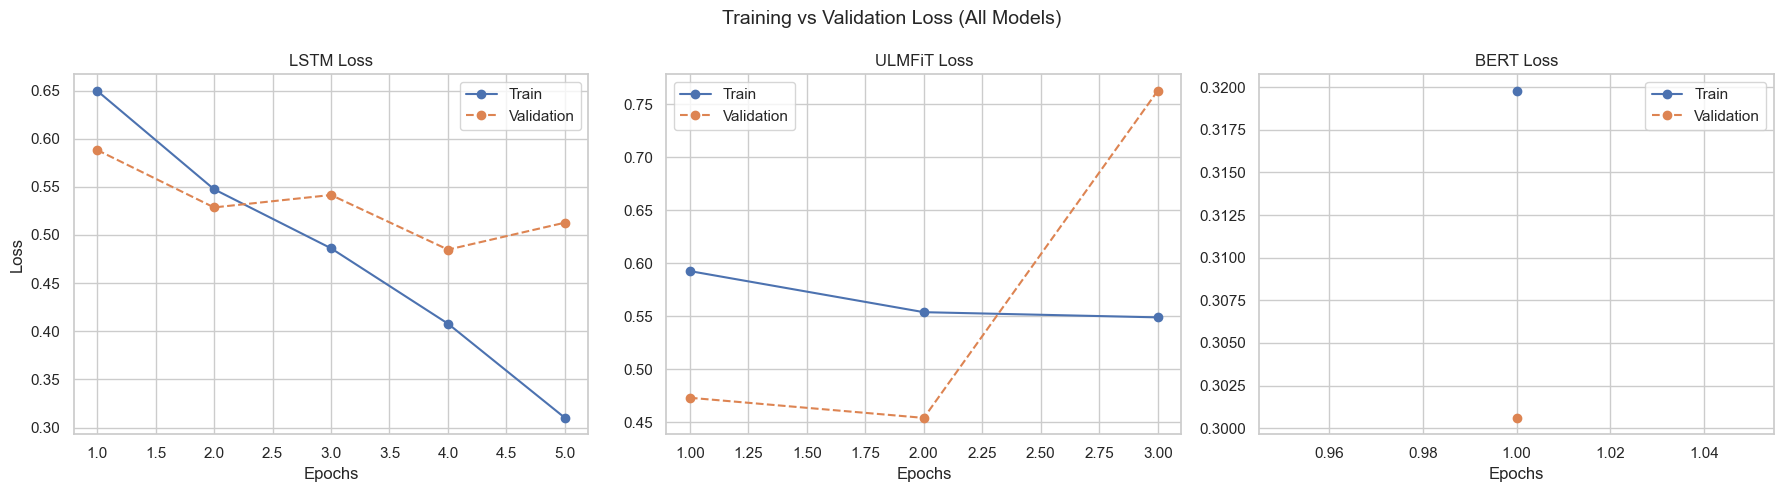

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ===== Data =====
lstm_train_loss = [0.6498, 0.5475, 0.4862, 0.4079, 0.3101]
lstm_val_loss   = [0.5883, 0.5286, 0.5415, 0.4848, 0.5128]

ulmfit_train_loss = [0.5926, 0.5538, 0.5489]
ulmfit_val_loss   = [0.4730, 0.4540, 0.7629]

bert_train_loss = [0.3198]
bert_val_loss   = [0.3006]

# ===== Create subplots =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ===== LSTM =====
epochs_lstm = range(1, len(lstm_train_loss)+1)
axes[0].plot(epochs_lstm, lstm_train_loss, marker='o', label="Train")
axes[0].plot(epochs_lstm, lstm_val_loss, marker='o', linestyle='--', label="Validation")
axes[0].set_title("LSTM Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# ===== ULMFiT =====
epochs_ulmfit = range(1, len(ulmfit_train_loss)+1)
axes[1].plot(epochs_ulmfit, ulmfit_train_loss, marker='o', label="Train")
axes[1].plot(epochs_ulmfit, ulmfit_val_loss, marker='o', linestyle='--', label="Validation")
axes[1].set_title("ULMFiT Loss")
axes[1].set_xlabel("Epochs")
axes[1].legend()

# ===== BERT =====
epochs_bert = range(1, len(bert_train_loss)+1)
axes[2].plot(epochs_bert, bert_train_loss, marker='o', label="Train")
axes[2].plot(epochs_bert, bert_val_loss, marker='o', linestyle='--', label="Validation")
axes[2].set_title("BERT Loss")
axes[2].set_xlabel("Epochs")
axes[2].legend()

# ===== Final touch =====
plt.suptitle("Training vs Validation Loss (All Models)", fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
trainer.save_model("/Users/Pooja/Documents/capstone_projects/projects/Sentiment analysis/bert_model")       # saves model
tokenizer.save_pretrained("/Users/Pooja/Documents/capstone_projects/projects/Sentiment analysis/bert_model")  # saves tokenizer

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/Users/Pooja/Documents/capstone_projects/projects/Sentiment analysis/bert_model/tokenizer_config.json',
 '/Users/Pooja/Documents/capstone_projects/projects/Sentiment analysis/bert_model/tokenizer.json')

In [32]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("/Users/Pooja/Documents/capstone_projects/projects/Sentiment analysis/bert_model")
tokenizer = AutoTokenizer.from_pretrained("/Users/Pooja/Documents/capstone_projects/projects/Sentiment analysis/bert_model")

model.eval()

def predict(text): 
    
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    pred = outputs.logits.argmax(dim=1).item()
    return "Positive" if pred == 1 else "Negative"

print(predict("I love this product"))
print(predict("This is terrible"))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Positive
Negative


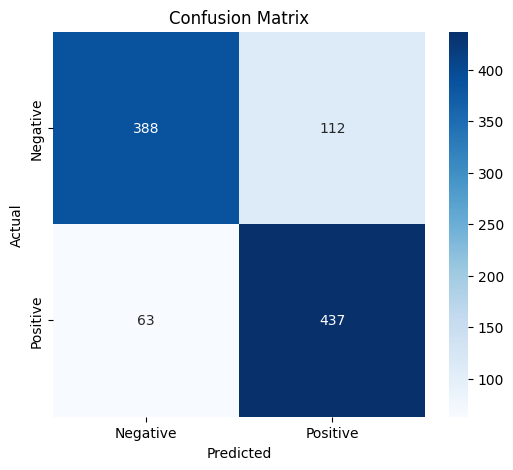

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

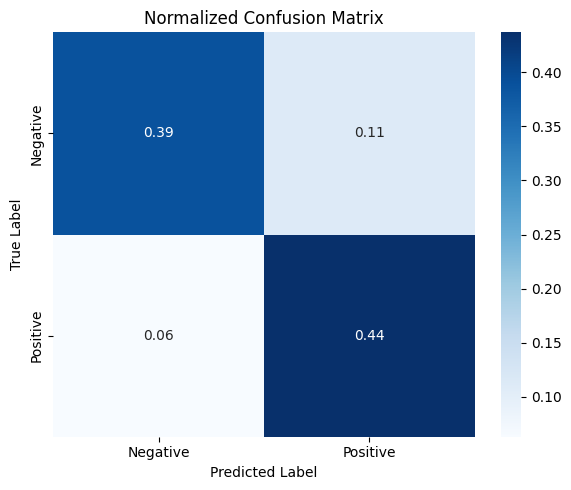

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm / cm.sum(), 
    annot=True, 
    fmt=".2f", 
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()